In [1]:
import pandas as pd

df = pd.read_csv("application_train.csv")

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
df.shape


(307511, 122)

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [5]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round(df.isnull().mean()*100, 2)
})

missing = missing.sort_values(
    "Missing %",
    ascending=False
)

missing.head(20)

,Missing Count,Missing %
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_MEDI,214865,69.87
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


In [6]:
missing[missing["Missing Count"] > 0]

,Missing Count,Missing %
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_MEDI,214865,69.87
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
...,...,...
EXT_SOURCE_2,660,0.21
AMT_GOODS_PRICE,278,0.09
AMT_ANNUITY,12,0.00
CNT_FAM_MEMBERS,2,0.00


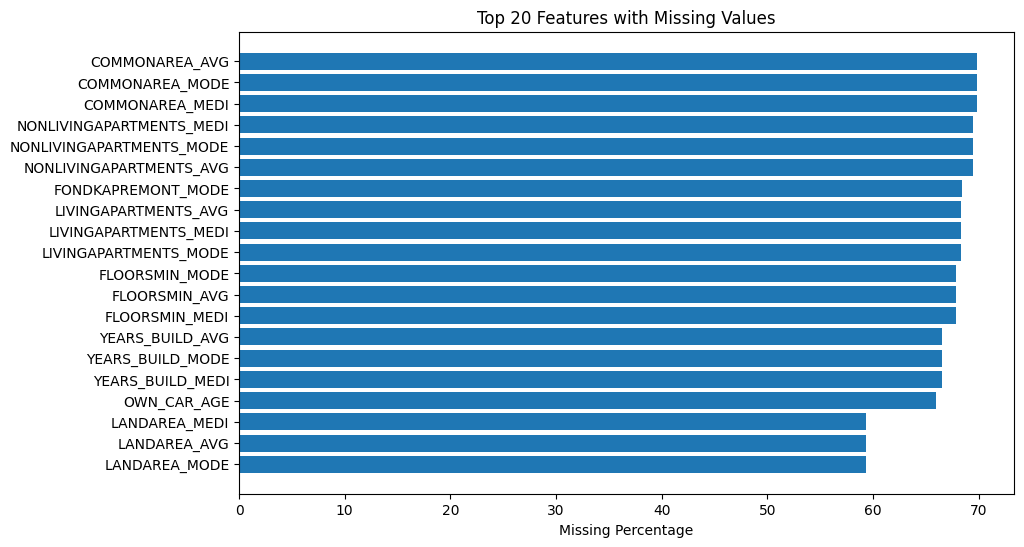

In [7]:
import matplotlib.pyplot as plt

top_missing = missing[missing["Missing %"] > 0].head(20)

plt.figure(figsize=(10,6))
plt.barh(top_missing.index, top_missing["Missing %"])
plt.xlabel("Missing Percentage")
plt.title("Top 20 Features with Missing Values")
plt.gca().invert_yaxis()
plt.show()

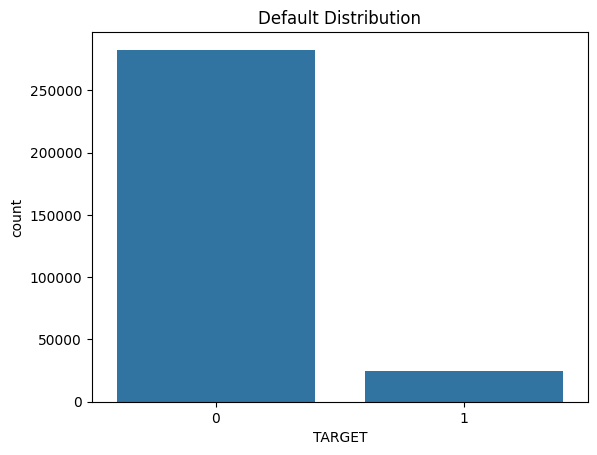

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='TARGET', data=df)

plt.title("Default Distribution")
plt.show()

In [9]:
df["TARGET"].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

In [10]:
df.duplicated().sum()

np.int64(0)

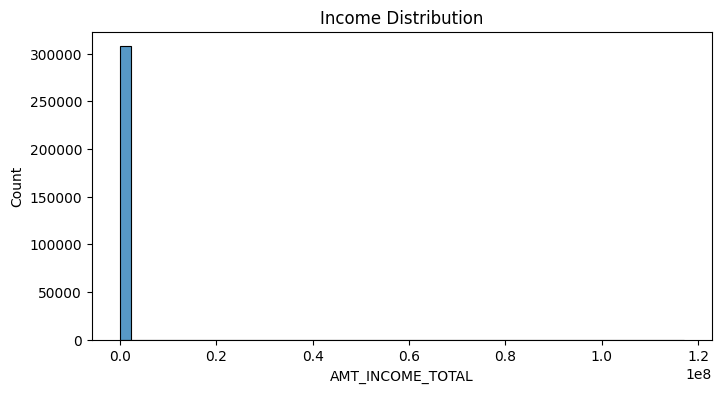

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df["AMT_INCOME_TOTAL"], bins=50)

plt.title("Income Distribution")
plt.show()

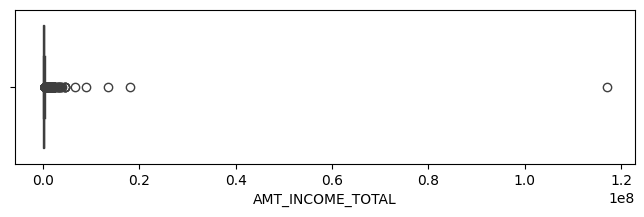

In [12]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df["AMT_INCOME_TOTAL"])

plt.show()

In [13]:
df["AMT_INCOME_TOTAL"].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [14]:
df["AMT_INCOME_TOTAL"].sort_values(
    ascending=False
).head(10)

12840     117000000.0
203693     18000090.0
246858     13500000.0
77768       9000000.0
131127      6750000.0
103006      4500000.0
287463      4500000.0
187833      4500000.0
204564      4500000.0
181698      3950059.5
Name: AMT_INCOME_TOTAL, dtype: float64

In [15]:
(df["DAYS_BIRTH"] / -365).describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

In [16]:
df["AGE"] = df["DAYS_BIRTH"] / -365

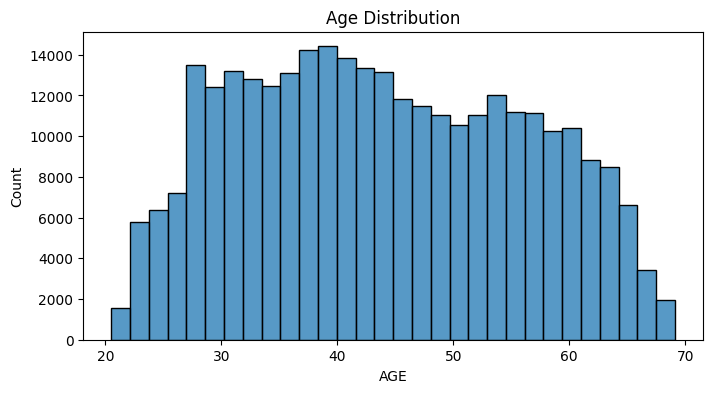

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(df["AGE"], bins=30)

plt.title("Age Distribution")
plt.show()

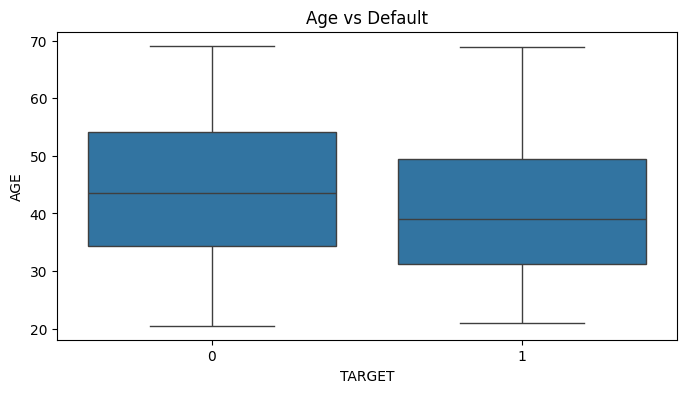

In [18]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x="TARGET",
    y="AGE",
    data=df
)

plt.title("Age vs Default")
plt.show()

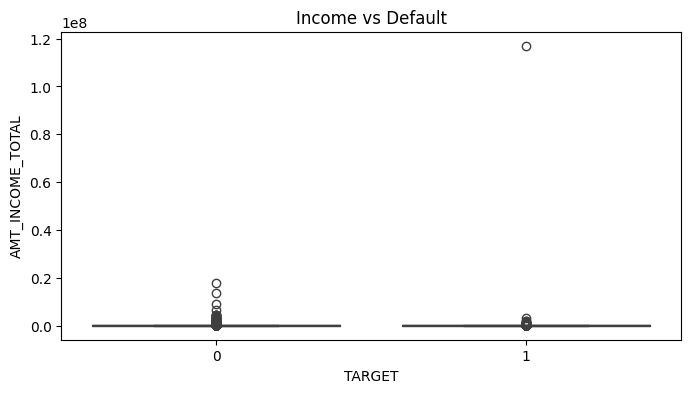

In [19]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x="TARGET",
    y="AMT_INCOME_TOTAL",
    data=df
)

plt.title("Income vs Default")
plt.show()

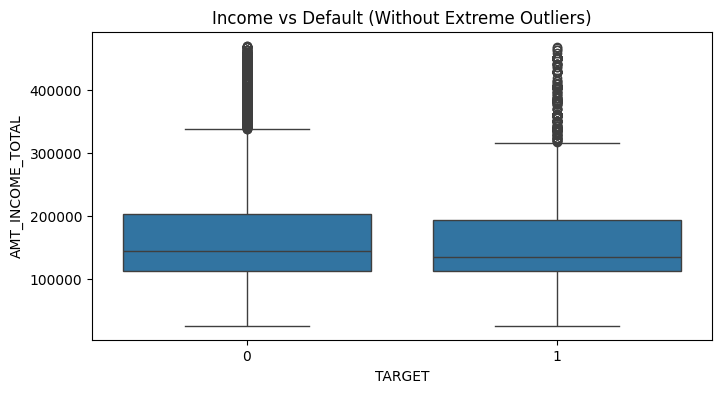

In [20]:
df_filtered = df[
    df["AMT_INCOME_TOTAL"] <
    df["AMT_INCOME_TOTAL"].quantile(0.99)
]

plt.figure(figsize=(8,4))

sns.boxplot(
    x="TARGET",
    y="AMT_INCOME_TOTAL",
    data=df_filtered
)

plt.title("Income vs Default (Without Extreme Outliers)")
plt.show()

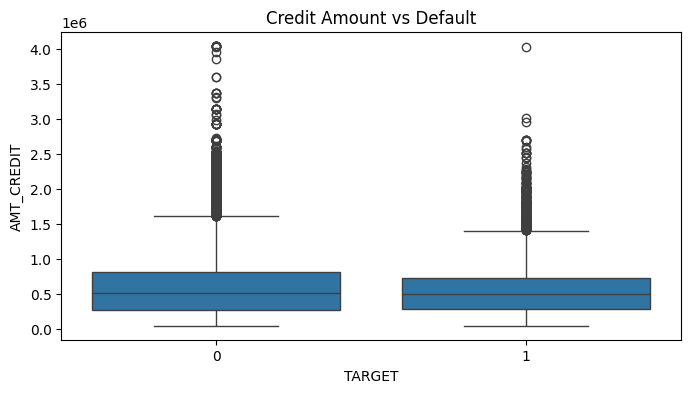

In [21]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x="TARGET",
    y="AMT_CREDIT",
    data=df
)

plt.title("Credit Amount vs Default")
plt.show()

In [22]:
corr_target = df.corr(numeric_only=True)["TARGET"]\
                .sort_values(ascending=False)

corr_target.head(15)

TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
DAYS_REGISTRATION              0.041975
OWN_CAR_AGE                    0.037612
LIVE_CITY_NOT_WORK_CITY        0.032518
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
Name: TARGET, dtype: float64

In [23]:
corr_target.tail(15)

LIVINGAREA_AVG               -0.032997
FLOORSMIN_MEDI               -0.033394
FLOORSMIN_AVG                -0.033614
ELEVATORS_MEDI               -0.033863
ELEVATORS_AVG                -0.034199
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_PRICE              -0.039645
FLOORSMAX_MODE               -0.043226
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_AVG                -0.044003
DAYS_EMPLOYED                -0.044932
AGE                          -0.078239
EXT_SOURCE_1                 -0.155317
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_3                 -0.178919
Name: TARGET, dtype: float64

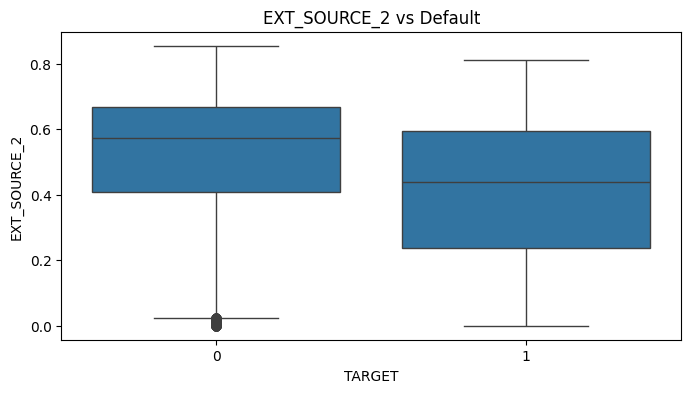

In [24]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x="TARGET",
    y="EXT_SOURCE_2",
    data=df
)

plt.title("EXT_SOURCE_2 vs Default")
plt.show()

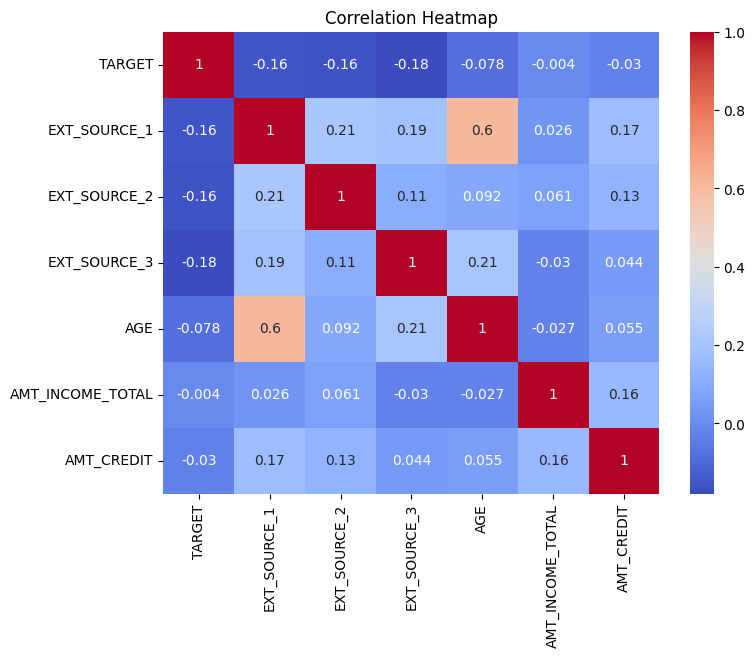

In [25]:
top_features = [
    "TARGET",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "AGE",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
## Key EDA Insights

1. Dataset contains 307,511 customers and 122 features.
2. Several housing-related features contain more than 60% missing values.
3. The target variable is highly imbalanced, with only ~8% defaults.
4. Income distribution is highly right-skewed and contains extreme outliers.
5. Younger customers exhibit higher default rates.
6. Income alone is not sufficient to distinguish risky customers.
7. Loan amount shows only weak separation between default groups.
8. External credit scores (EXT_SOURCE_1/2/3) are the strongest predictors of default risk.